In [1]:
import pandas as pd
import os
from nilearn import plotting
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from pathlib import Path
from nilearn.image import resample_to_img, math_img
from nilearn import plotting, image, datasets
from scipy.ndimage import label
import numpy as np
import matplotlib.pyplot as plt
from atlasreader import create_output
import re
import pathlib

The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data



In [2]:
whichVersion = 'persentence' #persentence, 3sec, 6sec

virtueORvice = 'virtues' # vices, virtues
whichStory = "shapes"
whichStory1 = "shapessocial"  
whichStory2 = "shapesphysical"  

whichFoundation = '3' # 1 to 7

# 1 to 7 maps onto the following foundations MAC:
# 1 = deference
# 2 = fairness
# 3 = family
# 4 = group
# 5 = heroism
# 6 = property
# 7 = reciprocity

# output directory

if whichVersion == "persentence":
    base_dir1 = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
    )
elif whichVersion == "3sec":
    base_dir1 = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation_3sec/"
    )
elif whichVersion == "6sec":
    base_dir1 = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation_6sec/"
    )
output_dir = Path(f"{base_dir1}{virtueORvice}/vsBaseline/compareGroups/{whichFoundation}/{whichStory}/")

# make the output directory if it does not exist: 
output_dir.mkdir(parents=True, exist_ok=True)

# results directory

if virtueORvice == 'virtues':
    virtueORviceDataFolder = '7_MAC'

if virtueORvice == 'vices':
    virtueORviceDataFolder = '7_MAC_V'

if whichVersion == "persentence":
    base_dir2 = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_0/"
    )
elif whichVersion == "3sec":
    base_dir2 = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_3/"
    )
elif whichVersion == "6sec":
    base_dir2 = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_6/"
    )

results_dir_affair = Path(f"{base_dir2}{whichStory1}/{virtueORviceDataFolder}/VsBaseline/")
results_dir_paranoia = Path(f"{base_dir2}{whichStory2}/{virtueORviceDataFolder}/VsBaseline/")

In [3]:
files_social = sorted(
    results_dir_affair.glob(f"*foundation{whichFoundation}_vsBaseline.nii.gz")
)

print(f"Found {len(files_social)} images.")


Found 58 images.


In [4]:
files_physical = sorted(
    results_dir_paranoia.glob(f"*foundation{whichFoundation}_vsBaseline.nii.gz")
)

print(f"Found {len(files_physical)} images.")

Found 58 images.


In [5]:

# 2. Convert PosixPaths → strings 
files_social = [str(f) for f in files_social]
files_physical = [str(f) for f in files_physical]


In [6]:

# 3. resample to same reference image
ref = files_social[0]
all_imgs = files_social + files_physical
imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]

# Split back into conditions after resampling
n_subs = len(files_social)
imgs_social = imgs_resampled[:n_subs]
imgs_physical = imgs_resampled[n_subs:]

# 4. Compute within-subject difference maps (social - physical)
diff_imgs = [
    math_img("img1 - img2", img1=s, img2=p)
    for s, p in zip(imgs_social, imgs_physical)
]

# 5. design matrix
design_matrix = pd.DataFrame({'intercept': [1] * len(diff_imgs)})

# 6. Initialize and fit the second-level model
second_level_model = SecondLevelModel()
second_level_model = second_level_model.fit(diff_imgs, design_matrix=design_matrix)

# 7. Compute contrasts
# (a) Social > Physical
z_map_social_over_physical = second_level_model.compute_contrast(
    'intercept', output_type='z_score'
)
z_map_social_over_physical.to_filename(
    str(output_dir) + '/social_over_physical_zmap.nii.gz'
)

# (b) Physical > Social
z_map_physical_over_social = second_level_model.compute_contrast(
    '-intercept', output_type='z_score'
)
z_map_physical_over_social.to_filename(
    str(output_dir) + '/physical_over_social_zmap.nii.gz'
)


/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_1752/2124634087.py:4: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


In [7]:
# do fdr correction
thresholded_map, threshold_1 = threshold_stats_img(
    z_map_social_over_physical, alpha=0.05, height_control='fdr'
)
thresholded_map.to_filename(str(output_dir)+'/social_over_physical_FDR05.nii.gz')

print(threshold_1)

create_output(str(output_dir)+'/social_over_physical_FDR05.nii.gz',
              cluster_extent=2,direction="pos",outdir=str(output_dir))


# do fdr correction
thresholded_map, threshold_2 = threshold_stats_img(
    z_map_physical_over_social, alpha=0.05, height_control='fdr'
)
thresholded_map.to_filename(str(output_dir)+'/physical_over_social_FDR05.nii.gz')

print(threshold_2)

create_output(str(output_dir)+'/physical_over_social_FDR05.nii.gz',
              cluster_extent=2,direction="pos",outdir=str(output_dir))

3.0976914139000553


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


3.0976914139000553


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


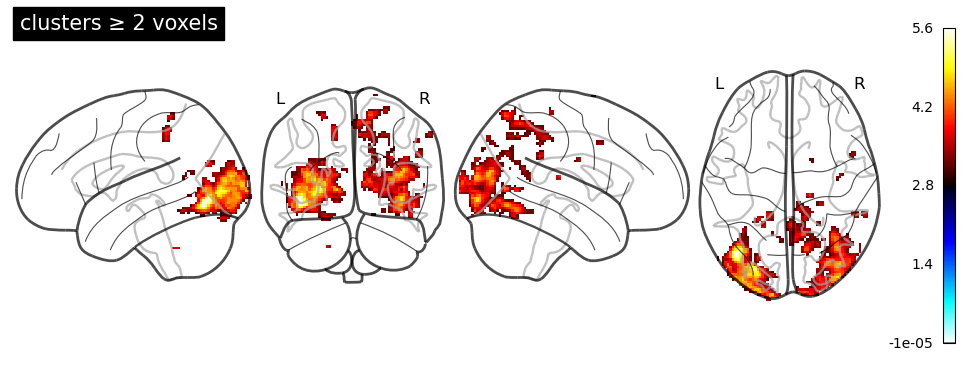

In [8]:
stat_img = image.load_img(str(output_dir)+'/social_over_physical_FDR05.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/social_over_physical_fdr05.png', dpi=300)  

plt.show()

display.close()

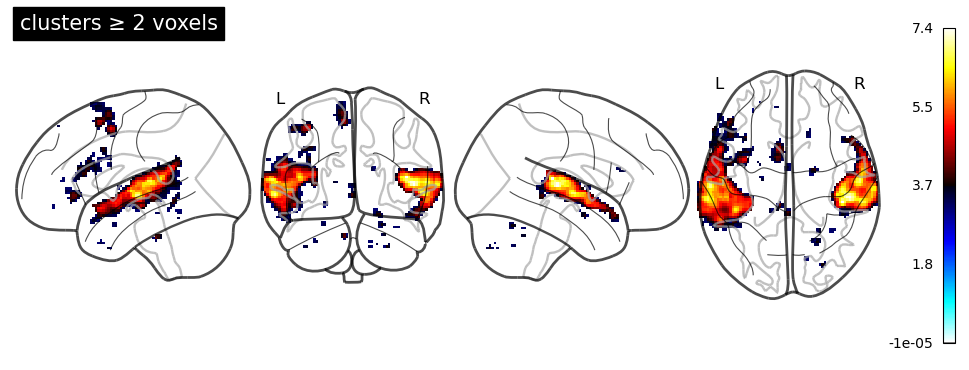

In [9]:
stat_img = image.load_img(str(output_dir)+'/physical_over_social_FDR05.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/physical_over_social_fdr05.png', dpi=300)  

plt.show()

display.close()

## split data based on task order

In [11]:
TaskOrder = pd.read_csv(base_dir1+'NarrativesParticipants.csv')
TaskOrder = TaskOrder[['BIDS ID','Notes','Manipulation']]
TaskOrder = TaskOrder.dropna(how='all')
# remove duplicate rows, only 1 row per participant
TaskOrder = TaskOrder[TaskOrder['Manipulation'] == 'social']


In [12]:

def classify_order(row):
    items = [x.strip() for x in row["Notes"].split(",")]
    # Find positions, return None if not present
    try:
        pos_social = items.index("social")
        pos_physical = items.index("physical")
    except ValueError:
        return None  # one of them missing

    if pos_social < pos_physical:
        return "social_first"
    elif pos_physical < pos_social:
        return "physical_first"
    else:
        return None

TaskOrder["order"] = TaskOrder.apply(classify_order, axis=1)

social_first_ids = TaskOrder.loc[TaskOrder["order"] == "social_first", "BIDS ID"].tolist()
physical_first_ids = TaskOrder.loc[TaskOrder["order"] == "physical_first", "BIDS ID"].tolist()

print("Social → Physical:", social_first_ids)
print("Physical → Social:", physical_first_ids)


Social → Physical: ['sub-049', 'sub-058', 'sub-181', 'sub-186', 'sub-190', 'sub-200', 'sub-206', 'sub-207', 'sub-208', 'sub-209', 'sub-210', 'sub-211', 'sub-212', 'sub-221', 'sub-222', 'sub-223', 'sub-224', 'sub-225', 'sub-226', 'sub-227', 'sub-228', 'sub-229', 'sub-230', 'sub-231', 'sub-232', 'sub-233', 'sub-234', 'sub-235', 'sub-236', 'sub-237']
Physical → Social: ['sub-095', 'sub-115', 'sub-127', 'sub-191', 'sub-201', 'sub-213', 'sub-214', 'sub-215', 'sub-216', 'sub-217', 'sub-218', 'sub-219', 'sub-220', 'sub-238', 'sub-239', 'sub-240', 'sub-241', 'sub-242', 'sub-243', 'sub-244', 'sub-245', 'sub-246', 'sub-247', 'sub-248', 'sub-249', 'sub-250', 'sub-251', 'sub-252', 'sub-253']


In [13]:

def extract_subid(path: Path):
    # Extract 3-digit ID
    m = re.search(r"/(\d{3})_", str(path))
    return f"sub-{m.group(1)}" if m else None



In [14]:
# split the social-shapes files
files_social_dict = {extract_subid(p): p for p in files_social}

socialfiles_social_first = [
    files_social_dict[sid] for sid in social_first_ids if sid in files_social_dict
]

socialfiles_physical_first = [
    files_social_dict[sid] for sid in physical_first_ids if sid in files_social_dict
]

print("Files: Social → Physical")
for f in socialfiles_social_first:
    print(f)

print("\nFiles: Physical → Social")
for f in socialfiles_physical_first:
    print(f)


Files: Social → Physical
/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_0/shapessocial/7_MAC/VsBaseline/049_shapessocial_0_7_MAC_z_map_foundation3_vsBaseline.nii.gz
/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_0/shapessocial/7_MAC/VsBaseline/058_shapessocial_0_7_MAC_z_map_foundation3_vsBaseline.nii.gz
/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_0/shapessocial/7_MAC/VsBaseline/181_shapessocial_0_7_MAC_z_map_foundation3_vsBaseline.nii.gz
/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoin

In [15]:
# split the physical-shapes files

files_physical_dict = {extract_subid(p): p for p in files_physical}

physicalfiles_social_first = [
    files_physical_dict[sid] for sid in social_first_ids if sid in files_physical_dict
]

physicalfiles_physical_first = [
    files_physical_dict[sid] for sid in physical_first_ids if sid in files_physical_dict
]

print("Files: Social → Physical")
for f in physicalfiles_social_first:
    print(f)

print("\nFiles: Physical → Social")
for f in physicalfiles_physical_first:
    print(f)

Files: Social → Physical
/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_0/shapesphysical/7_MAC/VsBaseline/049_shapesphysical_0_7_MAC_z_map_foundation3_vsBaseline.nii.gz
/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_0/shapesphysical/7_MAC/VsBaseline/058_shapesphysical_0_7_MAC_z_map_foundation3_vsBaseline.nii.gz
/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_0/shapesphysical/7_MAC/VsBaseline/181_shapesphysical_0_7_MAC_z_map_foundation3_vsBaseline.nii.gz
/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/res

# run a mixed model

In [17]:
# Ensure strings
socialfiles_social_first     = [str(f) for f in socialfiles_social_first]
physicalfiles_social_first   = [str(f) for f in physicalfiles_social_first]
socialfiles_physical_first   = [str(f) for f in socialfiles_physical_first]
physicalfiles_physical_first = [str(f) for f in physicalfiles_physical_first]

# Output dir
output_dir = str(output_dir) + "/group_results"
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# Helper: FDR-threshold + save NIfTI + save glass PNG + call create_output()
# -------------------------
def save_fdr_glass(stat_img, title, filename_stem, q=0.05):

    # FDR threshold
    thr_img, thr = threshold_stats_img(stat_img, alpha=q, height_control='fdr')

    # ---- Save thresholded NIfTI ----
    thr_nifti_path = os.path.join(output_dir, filename_stem + "_fdr05.nii.gz")
    thr_img.to_filename(thr_nifti_path)

    # ---- Save PNG ----
    display = plotting.plot_glass_brain(
        thr_img,
        colorbar=True,
        display_mode='lyrz',
        plot_abs=False,
        cmap='cold_hot',
        title=title
    )
    png_path = os.path.join(output_dir, filename_stem + "_fdr05_glassbrain.png")
    display.savefig(png_path, dpi=300)
    display.close()

    print(f"Saved NIfTI: {thr_nifti_path}")
    print(f"Saved PNG  : {png_path}")
    print(f"FDR threshold: {thr}")

    # For negative direction: invert the stat_img and re-threshold
    thr_img_neg, thr_neg = threshold_stats_img(
        image.math_img("img * -1", img=stat_img), 
        alpha=q, 
        height_control="fdr"
    )
    thr_nifti_path_neg = os.path.join(output_dir, filename_stem + "_fdr05_NEG.nii.gz")
    thr_img_neg.to_filename(thr_nifti_path_neg)

    return thr_nifti_path, thr_nifti_path_neg


# -------------------------
# 1) Compute subject-wise difference maps
# -------------------------
diff_sf = []
for soc, phys in zip(socialfiles_social_first, physicalfiles_social_first):
    diff_sf.append(image.math_img("img1 - img2", img1=soc, img2=phys))

diff_pf = []
for soc, phys in zip(socialfiles_physical_first, physicalfiles_physical_first):
    diff_pf.append(image.math_img("img1 - img2", img1=soc, img2=phys))


# -------------------------
# 2) WITHIN-GROUP one-sample tests
# -------------------------

# SOCIAL FIRST group
if len(diff_sf) > 0:
    design_sf = pd.DataFrame({"intercept": np.ones(len(diff_sf))})
    slm_sf = SecondLevelModel().fit(diff_sf, design_matrix=design_sf)

    # Social > Physical
    z_sf_sp = slm_sf.compute_contrast("intercept", output_type='z_score')
    save_fdr_glass(
        z_sf_sp,
        "social_first: Social > Physical (one-sample)",
        "sf_social_gt_physical"
    )

    # Physical > Social
    z_sf_ps = image.math_img("img * -1", img=z_sf_sp)
    save_fdr_glass(
        z_sf_ps,
        "social_first: Physical > Social (one-sample)",
        "sf_physical_gt_social"
    )

# PHYSICAL FIRST group
if len(diff_pf) > 0:
    design_pf = pd.DataFrame({"intercept": np.ones(len(diff_pf))})
    slm_pf = SecondLevelModel().fit(diff_pf, design_matrix=design_pf)

    # Social > Physical
    z_pf_sp = slm_pf.compute_contrast("intercept", output_type='z_score')
    save_fdr_glass(
        z_pf_sp,
        "physical_first: Social > Physical (one-sample)",
        "pf_social_gt_physical"
    )

    # Physical > Social
    z_pf_ps = image.math_img("img * -1", img=z_pf_sp)
    save_fdr_glass(
        z_pf_ps,
        "physical_first: Physical > Social (one-sample)",
        "pf_physical_gt_social"
    )

# -------------------------
# 3) BETWEEN-GROUP: (social - physical) difference maps
# -------------------------
all_diffs = diff_sf + diff_pf
if len(all_diffs) > 0:
    group_col = [1]*len(diff_sf) + [0]*len(diff_pf)
    design_diffs = pd.DataFrame({"intercept": np.ones(len(all_diffs)), "group": group_col})
    slm_diffs = SecondLevelModel().fit(all_diffs, design_matrix=design_diffs)

    # SF > PF
    z_diff_group_pos = slm_diffs.compute_contrast("group", output_type='z_score')
    save_fdr_glass(
        z_diff_group_pos,
        "(social-physical): social_first > physical_first",
        "between_diff_sf_gt_pf"
    )

    # PF > SF
    z_diff_group_neg = image.math_img("img * -1", img=z_diff_group_pos)
    save_fdr_glass(
        z_diff_group_neg,
        "(social-physical): physical_first > social_first",
        "between_diff_pf_gt_sf"
    )

# -------------------------
# 4) BETWEEN-GROUP: Social-only maps
# -------------------------
social_all = socialfiles_social_first + socialfiles_physical_first
if len(social_all) > 0:
    group_col_social = [1] * len(socialfiles_social_first) + [0] * len(socialfiles_physical_first)
    design_social = pd.DataFrame({"intercept": np.ones(len(social_all)), "group": group_col_social})

    slm_social = SecondLevelModel().fit(social_all, design_matrix=design_social)

    z_social_group_pos = slm_social.compute_contrast("group", output_type='z_score')
    save_fdr_glass(z_social_group_pos,
                   "Social maps: social_first > physical_first",
                   "social_maps_sf_gt_pf")

    z_social_group_neg = image.math_img("img * -1", img=z_social_group_pos)
    save_fdr_glass(z_social_group_neg,
                   "Social maps: physical_first > social_first",
                   "social_maps_pf_gt_sf")

# -------------------------
# 5) BETWEEN-GROUP: Physical-only maps
# -------------------------
physical_all = physicalfiles_social_first + physicalfiles_physical_first
if len(physical_all) > 0:
    group_col_phys = [1] * len(physicalfiles_social_first) + [0] * len(physicalfiles_physical_first)
    design_phys = pd.DataFrame({"intercept": np.ones(len(physical_all)), "group": group_col_phys})

    slm_physical = SecondLevelModel().fit(physical_all, design_matrix=design_phys)

    z_phys_group_pos = slm_physical.compute_contrast("group", output_type='z_score')
    save_fdr_glass(z_phys_group_pos,
                   "Physical maps: social_first > physical_first",
                   "physical_maps_sf_gt_pf")

    z_phys_group_neg = image.math_img("img * -1", img=z_phys_group_pos)
    save_fdr_glass(z_phys_group_neg,
                   "Physical maps: physical_first > social_first",
                   "physical_maps_pf_gt_sf")

print("All contrasts computed and outputs generated.")


Saved NIfTI: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/sf_social_gt_physical_fdr05.nii.gz
Saved PNG  : /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/sf_social_gt_physical_fdr05_glassbrain.png
FDR threshold: 3.594257137285976
Saved NIfTI: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/sf_physical_gt_social_fdr05.nii.gz
Saved PNG  : /Users/silvyc

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.9953615824494566. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:313: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)


Saved NIfTI: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/between_diff_sf_gt_pf_fdr05.nii.gz
Saved PNG  : /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/between_diff_sf_gt_pf_fdr05_glassbrain.png
FDR threshold: inf
Saved NIfTI: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/between_diff_pf_gt_sf_fdr05.nii.gz
Saved PNG  : /Users/silvycollin/Library/

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.2177946786865235. But, you have given threshold=inf.
  stat_img = threshold_img(


Saved NIfTI: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/social_maps_sf_gt_pf_fdr05.nii.gz
Saved PNG  : /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/social_maps_sf_gt_pf_fdr05_glassbrain.png
FDR threshold: inf
Saved NIfTI: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/social_maps_pf_gt_sf_fdr05.nii.gz
Saved PNG  : /Users/silvycollin/Library/Clo

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.145298405959202. But, you have given threshold=inf.
  stat_img = threshold_img(


Saved NIfTI: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/physical_maps_sf_gt_pf_fdr05.nii.gz
Saved PNG  : /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/physical_maps_sf_gt_pf_fdr05_glassbrain.png
FDR threshold: inf
Saved NIfTI: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/physical_maps_pf_gt_sf_fdr05.nii.gz
Saved PNG  : /Users/silvycollin/Libra

Found 20 NIfTI files in /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results
Processing: between_diff_pf_gt_sf_fdr05.nii.gz


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:313: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)


Processing: between_diff_pf_gt_sf_fdr05_NEG.nii.gz


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:313: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)


Processing: between_diff_sf_gt_pf_fdr05.nii.gz


...

Processing: pf_physical_gt_social_fdr05_NEG.nii.gz


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


Processing: pf_social_gt_physical_fdr05.nii.gz


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


OSError: [Errno 89] Operation canceled: '/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/vsBaseline/compareGroups/3/shapes/group_results/pf_social_gt_physical_fdr05_cluster06.png'

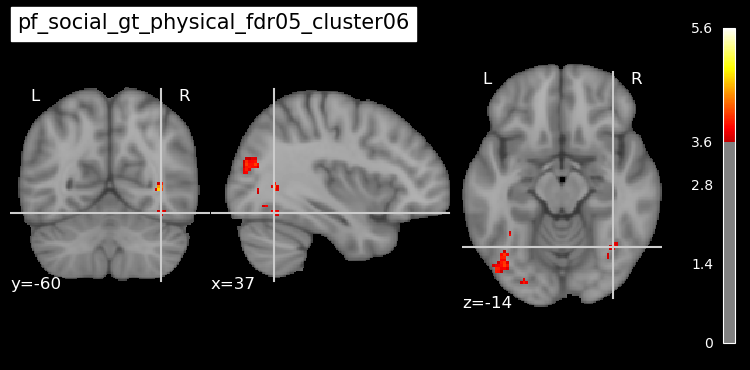

In [18]:
# Folder containing .nii.gz images 
output_dir_path = pathlib.Path(output_dir)

# List all .nii.gz images in the folder
nii_files = sorted(output_dir_path.glob("*.nii.gz"))

print(f"Found {len(nii_files)} NIfTI files in {output_dir_path}")

# Run create_output on each file
for nii_path in nii_files:
    print(f"Processing: {nii_path.name}")
    
    # Output base name (same folder)
    output_base = output_dir_path / (nii_path.stem + "_processed")
    
    # Run create_output (positional argument for the input NIfTI)
    create_output(
        str(nii_path),      
        cluster_extent=2,
        direction="pos",    
        outdir=str(output_dir_path)
    )

print("All .nii.gz images processed with create_output.")
